# Titanic Survival Prediction

Objective:
To analyze passenger data and identify factors affecting survival.

 **Importing libraries and dataset**

In [ ]:
import numpy as np
import pandas as pd
import pylab as plt

from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

# Set the global size of Matplot figures
plt.rc('figure',figsize=(10,5))

# Set the size of subplots
size_subplot=(10,10)

# Size of Histogram Bins
bin_size=10

In [ ]:
df_t = pd.read_csv('/content/train.csv')

In [ ]:
# Check the top five rows and columns of my Dataset
df_t.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
#check the bottom five rows of Dataset
df_t.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
#no. of total rows and columns
df_t.shape

(891, 12)

**Viewing the info about the dataset**

In [ ]:
# Display the datatypes of dataset
df_t.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
# Showing info about dataset maybe null values
df_t.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
#  Displaying total number of null values (only is null function provides true and false for each row value so sum function is also used here)
df_t.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**Handling missing values**

In [ ]:
# Adding empty values at the place of missing values in the age column
df_t['Age'] = df_t['Age'].fillna(df_t['Age'].mean())
df_t.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Replacing missing values with the most repeated one in embarked
df_t['Embarked'] = df_t['Embarked'].fillna(df_t['Embarked'].mode()[0])
df_t.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
#Removing empty values in the cabin
df_t.drop('Cabin', axis=1, inplace=True)
df_t.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df_t.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Visualisation**

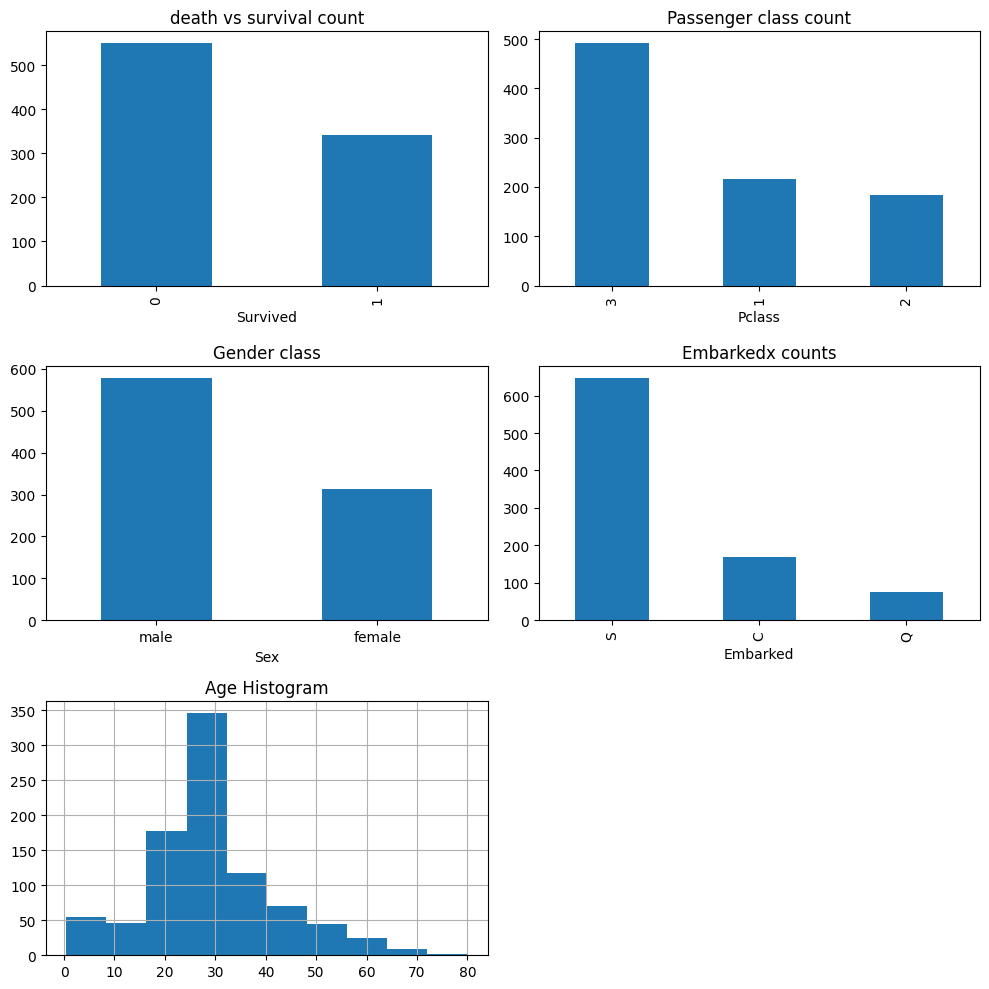

In [ ]:
fig=plt.figure(figsize=size_subplot)
fig_dims=(3,2)

plt.subplot2grid(fig_dims, (0,0))
df_t['Survived'].value_counts().plot(kind='bar',title='death vs survival count')

plt.subplot2grid (fig_dims, (0,1))
df_t['Pclass'].value_counts().plot(kind='bar',title='Passenger class count')

plt.subplot2grid(fig_dims, (1,0))
df_t['Sex'].value_counts().plot(kind='bar',title='Gender class')

plt.xticks(rotation=0)

plt.subplot2grid(fig_dims, (1,1))
df_t['Embarked'].value_counts().plot(kind='bar',title='Embarkedx counts')

plt.subplot2grid(fig_dims, (2,0))
df_t['Age'].hist()
plt.title("Age Histogram")

plt.tight_layout()
plt.show()

**Insights:**

*   The number of passengers who did not survive was higher than the number of survivors.
*   This shows that the overall survival rate on Titanic was low.



**Feature: Passenger Class**

In [ ]:
pclass_xt=pd.crosstab(df_t['Pclass'],df_t['Survived'])
pclass_xt

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


Text(0, 0.5, 'Survival Rate')

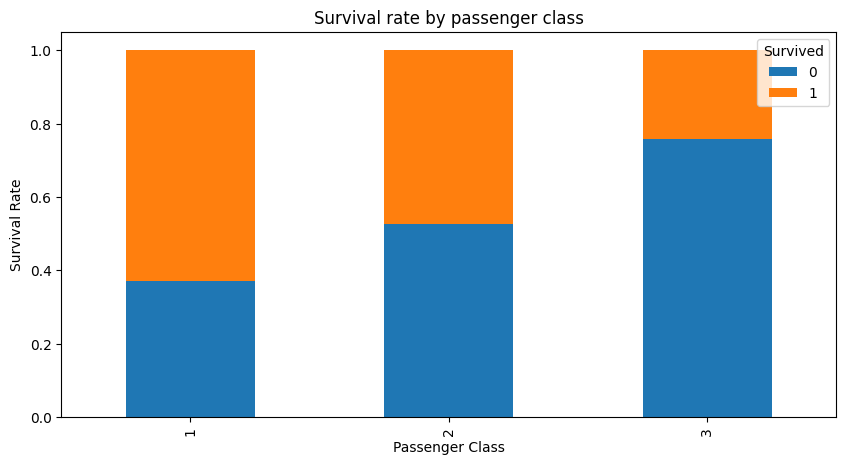

In [ ]:
pclass_xt_pct= pclass_xt.div(pclass_xt.sum(1).astype(float), axis=0)

pclass_xt_pct.plot(kind='bar', stacked= True,
                   title='Survival rate by passenger class')
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

**Insights:**

*  First-class passengers had a higher survival rate compared to second and third class.

* Passenger class appears to have an impact on survival chances.




**Feature:Gender**

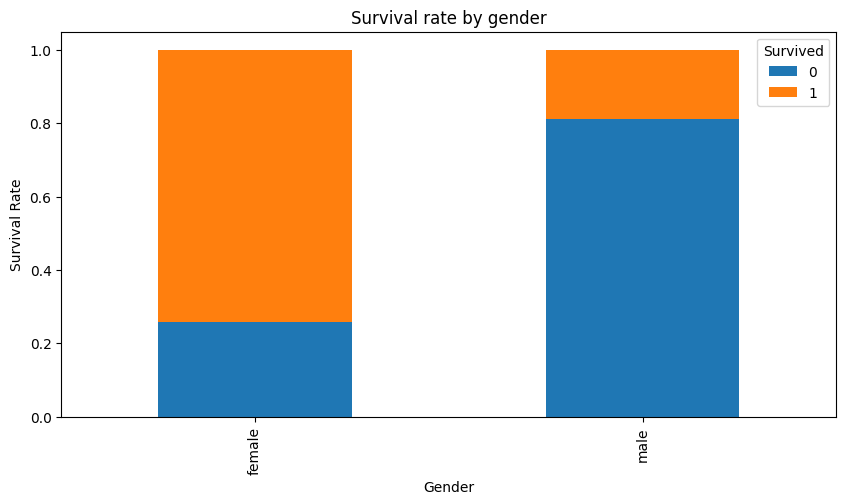

In [ ]:
gender_xt = pd.crosstab(df_t['Sex'], df_t['Survived'])

gender_xt_pct = gender_xt.div(gender_xt.sum(1).astype(float),axis=0 )

gender_xt_pct.plot( kind='bar',stacked=True, title='Survival rate by gender')

plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.show()

**Insights:**


*   Female passengers had a significantly higher survival rate than male passengers.
*   This suggests gender was an important factor in survival.



In [ ]:
# Unique values of P class
passenger_class = sorted (df_t['Pclass'].unique())

for p_class in passenger_class:
  print('M-',p_class, len(df_t[(df_t['Sex']=='male')&
                         (df_t['Pclass']==p_class)]))
  print('F-', p_class, len(df_t[(df_t['Sex']=='female')&
                          (df_t['Pclass']==p_class)]))

M- 1 122
F- 1 94
M- 2 108
F- 2 76
M- 3 347
F- 3 144


Text(0, 0.5, 'Survival rate')

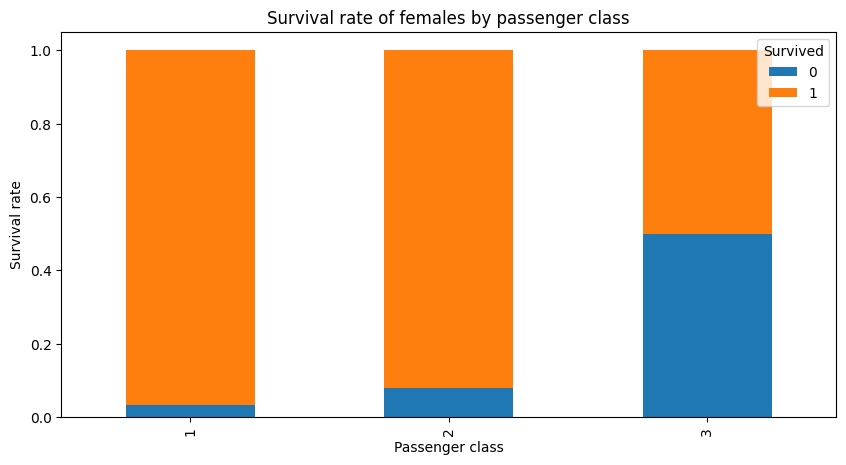

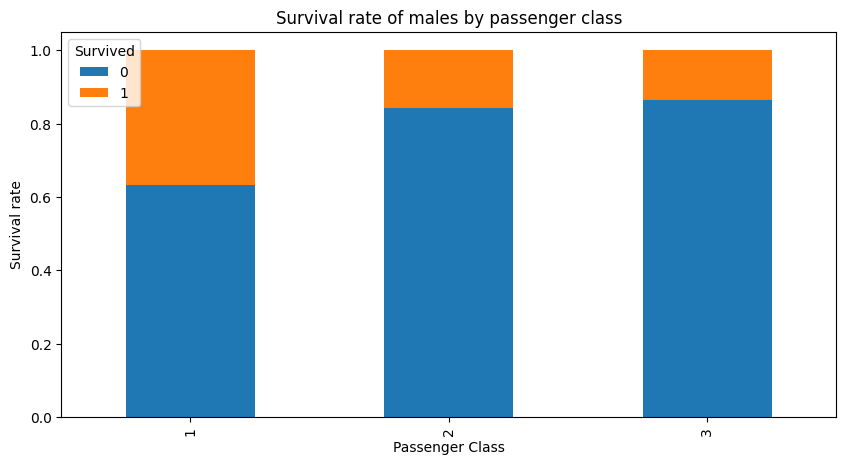

In [ ]:
females_df=df_t[df_t['Sex']=='female']
females_xt = pd.crosstab(females_df['Pclass'],df_t['Survived'])
females_xt_pct =females_xt.div(females_xt.sum(1).astype(float), axis=0)
females_xt_pct.plot(kind='bar',
                    stacked='True',
                    title= 'Survival rate of females by passenger class')

plt.xlabel('Passenger class')
plt.ylabel('Survival rate')

#---------------------------------------------------------------

males_df=df_t[df_t['Sex']=='male']
males_xt=pd.crosstab(males_df['Pclass'],df_t['Survived'])
males_xt_pct =males_xt.div(males_xt.sum(1).astype(float),axis=0)
males_xt_pct.plot(kind='bar',
                  stacked='True',
                  title='Survival rate of males by passenger class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival rate')

**Insights:**

*  Females generally had higher survival rates across passenger classes.
*   Third-class passengers had lower survival chances compared to higher classes.



**Correlation Analysis**

In [ ]:
df_t.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.033207,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.069809,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.331339,0.083081,0.018443,-0.549500
Age,0.033207,-0.069809,-0.331339,1.000000,-0.232625,-0.179191,0.091566
SibSp,-0.057527,-0.035322,0.083081,-0.232625,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.179191,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.091566,0.159651,0.216225,1.000000


**Conclusion:**


*   Missing values were handled successfully before analysis.
*   Female passengers had higher survival rates compared to male passengers.
*   First-class passengers had better survival chances.
*   Passenger class and gender were important factors affecting survival.
*   Third-class passengers had the highest number of deaths.
*   Data visualization helped identify patterns and relationships in the dataset.





